In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
# Load a subset first (efficient)
dataset = load_dataset("scikit-learn/adult-census-income", split="train[:5000]")

df = pd.DataFrame(dataset)

# Randomly select 2000 rows
df = df.sample(n=2000, random_state=42).reset_index(drop=True)

df.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,39,State-gov,119421,HS-grad,9,Separated,Adm-clerical,Unmarried,White,Female,0,625,35,United-States,<=50K
1,53,Self-emp-not-inc,135339,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,Asian-Pac-Islander,Male,7688,0,20,China,>50K
2,42,Private,402367,Some-college,10,Married-civ-spouse,Transport-moving,Husband,Black,Male,7688,0,45,United-States,>50K
3,37,Private,200598,Assoc-acdm,12,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,1740,45,United-States,<=50K
4,44,Private,35910,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,1902,56,United-States,>50K


In [ ]:
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             2000 non-null   int64 
 1   workclass       2000 non-null   object
 2   fnlwgt          2000 non-null   int64 
 3   education       2000 non-null   object
 4   education.num   2000 non-null   int64 
 5   marital.status  2000 non-null   object
 6   occupation      2000 non-null   object
 7   relationship    2000 non-null   object
 8   race            2000 non-null   object
 9   sex             2000 non-null   object
 10  capital.gain    2000 non-null   int64 
 11  capital.loss    2000 non-null   int64 
 12  hours.per.week  2000 non-null   int64 
 13  native.country  2000 non-null   object
 14  income          2000 non-null   object
dtypes: int64(6), object(9)
memory usage: 234.5+ KB


Index(['age', 'workclass', 'fnlwgt', 'education', 'education.num',
       'marital.status', 'occupation', 'relationship', 'race', 'sex',
       'capital.gain', 'capital.loss', 'hours.per.week', 'native.country',
       'income'],
      dtype='object')

In [ ]:
df = df.replace("?", np.nan)
df = df.dropna()

In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
X = df.drop('income_>50K', axis=1)
y = df['income_>50K']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [ ]:
y_pred = knn.predict(X_test_scaled)

print("=== KNN Results ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

=== KNN Results ===
Accuracy: 0.7319034852546917

Classification Report:
               precision    recall  f1-score   support

       False       0.70      0.70      0.70       166
        True       0.76      0.75      0.76       207

    accuracy                           0.73       373
   macro avg       0.73      0.73      0.73       373
weighted avg       0.73      0.73      0.73       373



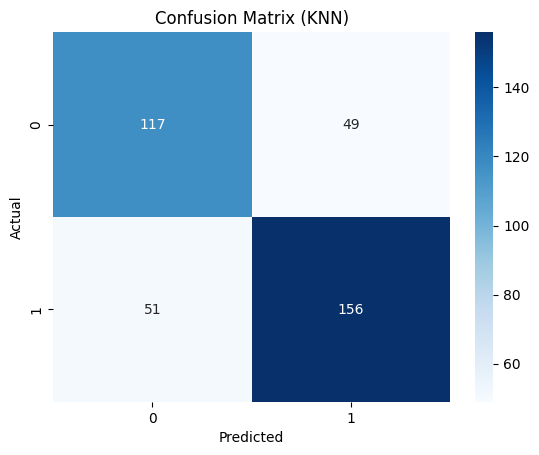

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (KNN)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

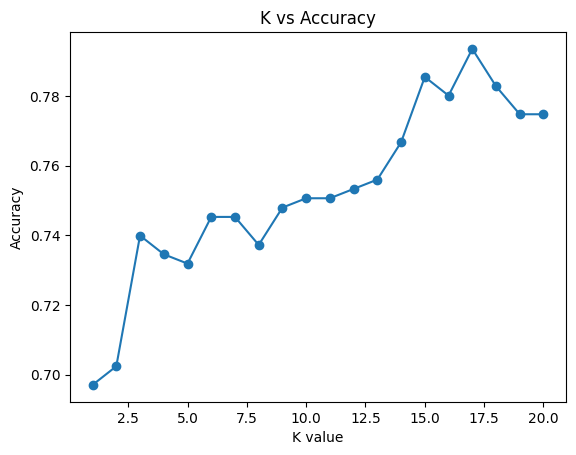

In [ ]:
k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred_k = knn.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, y_pred_k))

plt.plot(k_values, accuracies, marker='o')
plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy")
plt.show()

In [ ]:
best_k = k_values[np.argmax(accuracies)]
best_k

17

## 📝 K-Nearest Neighbors (KNN) Classification – Adult Census Income Dataset

This experiment implements the K-Nearest Neighbors (KNN) algorithm on a real-world dataset (`scikit-learn/adult-census-income`) to perform classification and evaluate model performance.

---

### 🔹 1. Objective
To implement the KNN algorithm and evaluate its performance using accuracy, classification report, and graphical analysis.

---

### 🔹 2. Dataset Description
The Adult Census Income dataset is a real-world dataset used to predict whether a person's income is:
- ≤50K  
- >50K  

Key characteristics:
- Contains both numerical and categorical features  
- Examples of features:
  - age, education, occupation, hours-per-week, etc.  
- Target variable: `income`  

For efficiency, only **2000 random samples** are used in this experiment.

---

### 🔹 3. Data Loading and Sampling
Since Hugging Face does not support random sampling during loading:
- A subset of 5000 rows is first loaded  
- Then 2000 rows are randomly selected  

This ensures:
- Faster execution  
- Random and unbiased data selection  

---

### 🔹 4. Data Preprocessing

#### ✔ Handling Missing Values
- Missing values represented as `"?"` are replaced with `NaN`  
- Rows with missing values are removed  

#### ✔ Encoding Categorical Variables
- One-hot encoding is applied using `pd.get_dummies()`  
- Converts categorical features into numerical form  

---

### 🔹 5. Feature and Target Selection
- Features (`X`) = all columns except `income`  
- Target (`y`) = `income`  

---

### 🔹 6. Train-Test Split
- 80% training data  
- 20% testing data  

Used to evaluate model performance on unseen data.

---

### 🔹 7. Feature Scaling
- Standardization is applied using `StandardScaler`  
- Ensures all features are on the same scale  

✔ Important because KNN is a **distance-based algorithm**

---

### 🔹 8. K-Nearest Neighbors (KNN)
- KNN is a **lazy learning algorithm**  
- It does not learn a model explicitly  
- It classifies a point based on the majority class of its nearest neighbors  

---

### 🔹 9. Model Evaluation

#### ✔ Accuracy Score
- Measures overall correctness of predictions  

#### ✔ Classification Report
- Precision → correctness of positive predictions  
- Recall → ability to detect all instances  
- F1-score → balance between precision and recall  

#### ✔ Confusion Matrix
- Shows actual vs predicted classifications  
- Helps identify misclassifications  

---

### 🔹 10. K vs Accuracy Graph
- Model is evaluated for different values of K (1 to 20)  
- Accuracy is plotted against K  

✔ Helps in selecting the **optimal value of K**

---

### 🔹 11. Best K Selection
- The value of K with highest accuracy is selected  
- Avoids:
  - Small K → overfitting  
  - Large K → underfitting  

---

### 🔹 12. Conclusion
- KNN performs well on structured datasets with proper preprocessing  
- Feature scaling significantly improves performance  
- Selecting optimal K is crucial for accuracy  
- Real-world datasets require preprocessing for effective modeling  

---

### 🧠 Key Learning
- KNN is simple but powerful for classification  
- Distance-based models require careful preprocessing  
- Hyperparameter tuning (K) directly impacts performance  